In [1]:
from anndata.utils import make_index_unique
from grnndata import utils as grnutils
from grnndata import read_h5ad

from matplotlib import pyplot as plt
from collections import defaultdict
import numpy as np
import pandas as pd

import gudhi
import networkx as nx
import itertools

%load_ext autoreload
%autoreload 2 

/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [ ]:
fig_dir = "adultSC_figures"
data_dir = "data"

## Adult

In [3]:
# load the generated gene networks from the previous notebook
grn_full = read_h5ad(f"{data_dir}/grn_sc_adult_10K_genes.h5ad")

In [4]:
# Remove duplicates and process gene symbols
grn_full.var.symbol = make_index_unique(grn_full.var.symbol.astype(str))

# Convert gene ids to symbols for better readability
grn_full.var['ensembl_id'] = grn_full.var.index
grn_full.var.index = grn_full.var.symbol

# Additional step: Remove any remaining duplicates after index assignment
if grn_full.var.index.duplicated().any():
    print(f"Found {grn_full.var.index.duplicated().sum()} duplicate entries after index assignment")
    grn_full = grn_full[:, ~grn_full.var.index.duplicated(keep='first')]
    print("Removed duplicate entries")

print(f"GRN shape: {grn_full.shape}")
print(f"Number of genes: {grn_full.n_vars}")
print(f"Number of cells/observations: {grn_full.n_obs}")

GRN shape: (1030, 10000)
Number of genes: 10000
Number of cells/observations: 1030


In [5]:
network_matrix = grn_full.grn

## Add-on 18

In [6]:
genes = ['SMOC2', 'LGR5', 'DMBT1', 'ASCL2', 'CA7', 'EPHB3', 'SOCS3', 'L1TD1', 'SCNN1A', 'LGALS2', 
         'RGMB', 'AKR1C3', 'REG4', 'RETNLB', 'SLC12A2', 'MUC12', 'SOX4', 'ADH1C', 'CDK6', 'CDCA7', 
         'RNF43', 'PDGFRA', 'SPIB', 'HES6','IL17RB', 'RRM2', 'TK1', 'TOP2A', 'CA2', 'FERMT1', 
         'MKI67', 'CPA3', 'CTSE', 'ANO7', 'DUOX2', 'DPYSL3', 'CTNNB1', 'KRT8', 'RGS13', 'PCLAF', 
         'NUSAP1', 'CES2', 'INSM1', 'GPX2', 'GALNT8', 'SULT1B1', 'SLC26A3', 'UBE2C', 'PROX1', 'KLK1',
        'ACTA2', 'PIGR', 'PLCE1', 'PSTPIP2', 'CA4']

In [7]:
len(genes)

55

In [8]:
print(f"Original network matrix shape: {network_matrix.shape}")
print(f"Total genes in 'genes' list: {len(genes)}")

Original network matrix shape: (10000, 10000)
Total genes in 'genes' list: 55


In [9]:
# Find genes from our list that are present in the network matrix
available_genes = [gene for gene in genes if gene in network_matrix.index]
missing_genes = [gene for gene in genes if gene not in network_matrix.index]
print(f"Genes from list present in network: {len(available_genes)}")
print(f"Genes from list missing from network: {len(missing_genes)}")

Genes from list present in network: 38
Genes from list missing from network: 17


In [10]:
# Extract subnetwork for genes of interest
genes_subset = network_matrix.loc[available_genes, :]

# Calculate connection strengths SPECIFICALLY to our genes of interest
# For each gene in the network, calculate how strongly it's connected to our genes of interest
connection_strengths_to_genes_of_interest = network_matrix.loc[:, available_genes].abs().sum(axis=1)

# Find the 95th percentile threshold (top 5% strongest connections TO our genes of interest)
threshold = np.percentile(connection_strengths_to_genes_of_interest, 97)

# Get genes with strong connections specifically TO our genes of interest
strongly_connected_genes = connection_strengths_to_genes_of_interest[connection_strengths_to_genes_of_interest >= threshold].index.tolist()

# Remove our original genes from the strongly connected genes list to avoid duplication
strongly_connected_genes = [gene for gene in strongly_connected_genes if gene not in available_genes]

print(f"Threshold for top 5% connections TO genes of interest: {threshold:.6f}")
print(f"Number of genes strongly connected TO our genes of interest: {len(strongly_connected_genes)}")
print(f"These are genes that have strong regulatory relationships with our {len(available_genes)} genes of interest")

Threshold for top 5% connections TO genes of interest: 0.008227
Number of genes strongly connected TO our genes of interest: 295
These are genes that have strong regulatory relationships with our 38 genes of interest


In [11]:
strongly_connected_genes

['SEMA3F',
 'ACSM3',
 'MYH13',
 'NOS2',
 'SLC13A2',
 'NOX1',
 'SYPL1',
 'PLEKHG6',
 'IYD',
 'NR1H4',
 'CHDH',
 'BEST2',
 'BARX2',
 'LAMA3',
 'ROPN1',
 'CHAT',
 'TRPM5',
 'SPP2',
 'CYP2W1',
 'ACACB',
 'CAPN6',
 'FAP',
 'SCTR',
 'CHRNA3',
 'SLC13A1',
 'OVGP1',
 'HSD17B2',
 'CETP',
 'SI',
 'ABCC6',
 'APOH',
 'SEMA4G',
 'IL11',
 'SMIM24',
 'PGC',
 'RPS18',
 'MISP',
 'HNF4A',
 'CST4',
 'WFDC2',
 'GPR143',
 'BMX',
 'VGLL1',
 'OLFM4',
 'MMP15',
 'CORO7-PAM16',
 'SLC6A2',
 'PDGFRL',
 'CALB1',
 'ANXA13',
 'ADAM2',
 'CEACAM5',
 'SYNGR4',
 'HAS1',
 'GAPDHS',
 'FSCN3',
 'MOGAT3',
 'PTGR1',
 'AMBP',
 'HOXB6',
 'SLC6A4',
 'CWH43',
 'ODAM',
 'BST1',
 'MEP1A',
 'IRX4',
 'AGXT2',
 'UPK1B',
 'GCA',
 'REG1A',
 'NPHS2',
 'PRG4',
 'PDC',
 'MUC5B',
 'FGF23',
 'HOXB8',
 'MOB3B',
 'MLANA',
 'NPPB',
 'PLBD1',
 'SFTPA1',
 'NFE2',
 'G0S2',
 'INHA',
 'MOGAT1',
 'NEURL2',
 'XG',
 'POF1B',
 'SCGB2A1',
 'BMP4',
 'FOXA2',
 'SLURP1',
 'STATH',
 'HTN1',
 'PZP',
 'VIL1',
 'VCY1B',
 'TNNI3',
 'ACE2',
 'RBBP8NL',
 'ACSS2'

In [12]:
# Combine original genes with strongly connected genes
final_gene_set = list(set(available_genes + strongly_connected_genes))

print(f"Total genes in final subset: {len(final_gene_set)}")

Total genes in final subset: 333


In [13]:
# Create final subsetted network matrix
network_matrix_subset = network_matrix.loc[final_gene_set, final_gene_set]

print(f"Final subsetted network matrix shape: {network_matrix_subset.shape}")

Final subsetted network matrix shape: (333, 333)


In [14]:
# filter genes
# Filter out genes that have no strong connections
# Calculate the sum of absolute values for each gene (row-wise and column-wise)
row_sums = np.abs(network_matrix_subset).sum(axis=1)
col_sums = np.abs(network_matrix_subset).sum(axis=0)

# Set a threshold for "strong connections" (you can adjust this)
connection_threshold = np.percentile(np.concatenate([row_sums, col_sums]), 50)  # 50th percentile

# Find genes that have strong connections (either as regulators or targets)
genes_with_strong_connections = []
for gene in network_matrix_subset.index:
    gene_row_sum = row_sums[gene]
    gene_col_sum = col_sums[gene]
    
    # Keep gene if it has strong connections either as a regulator or as a target
    if gene_row_sum >= connection_threshold or gene_col_sum >= connection_threshold:
        genes_with_strong_connections.append(gene)

print(f"Original network matrix subset shape: {network_matrix_subset.shape}")
print(f"Connection threshold (50th percentile): {connection_threshold:.6f}")
print(f"Genes with strong connections: {len(genes_with_strong_connections)}")
print(f"Genes filtered out: {network_matrix_subset.shape[0] - len(genes_with_strong_connections)}")

# Create filtered network matrix
network_matrix_subset_filtered = network_matrix_subset.loc[genes_with_strong_connections, genes_with_strong_connections]
print(f"Filtered network matrix shape: {network_matrix_subset_filtered.shape}")

# Update the network_matrix_subset variable to use the filtered version
network_matrix_subset = network_matrix_subset_filtered

Original network matrix subset shape: (333, 333)
Connection threshold (50th percentile): 0.006516
Genes with strong connections: 315
Genes filtered out: 18
Filtered network matrix shape: (315, 315)


Network visualization graph: 315 nodes, 213 edges
Edge threshold (top 25% connections): 0.0006
Edges shown: ALL connections above threshold


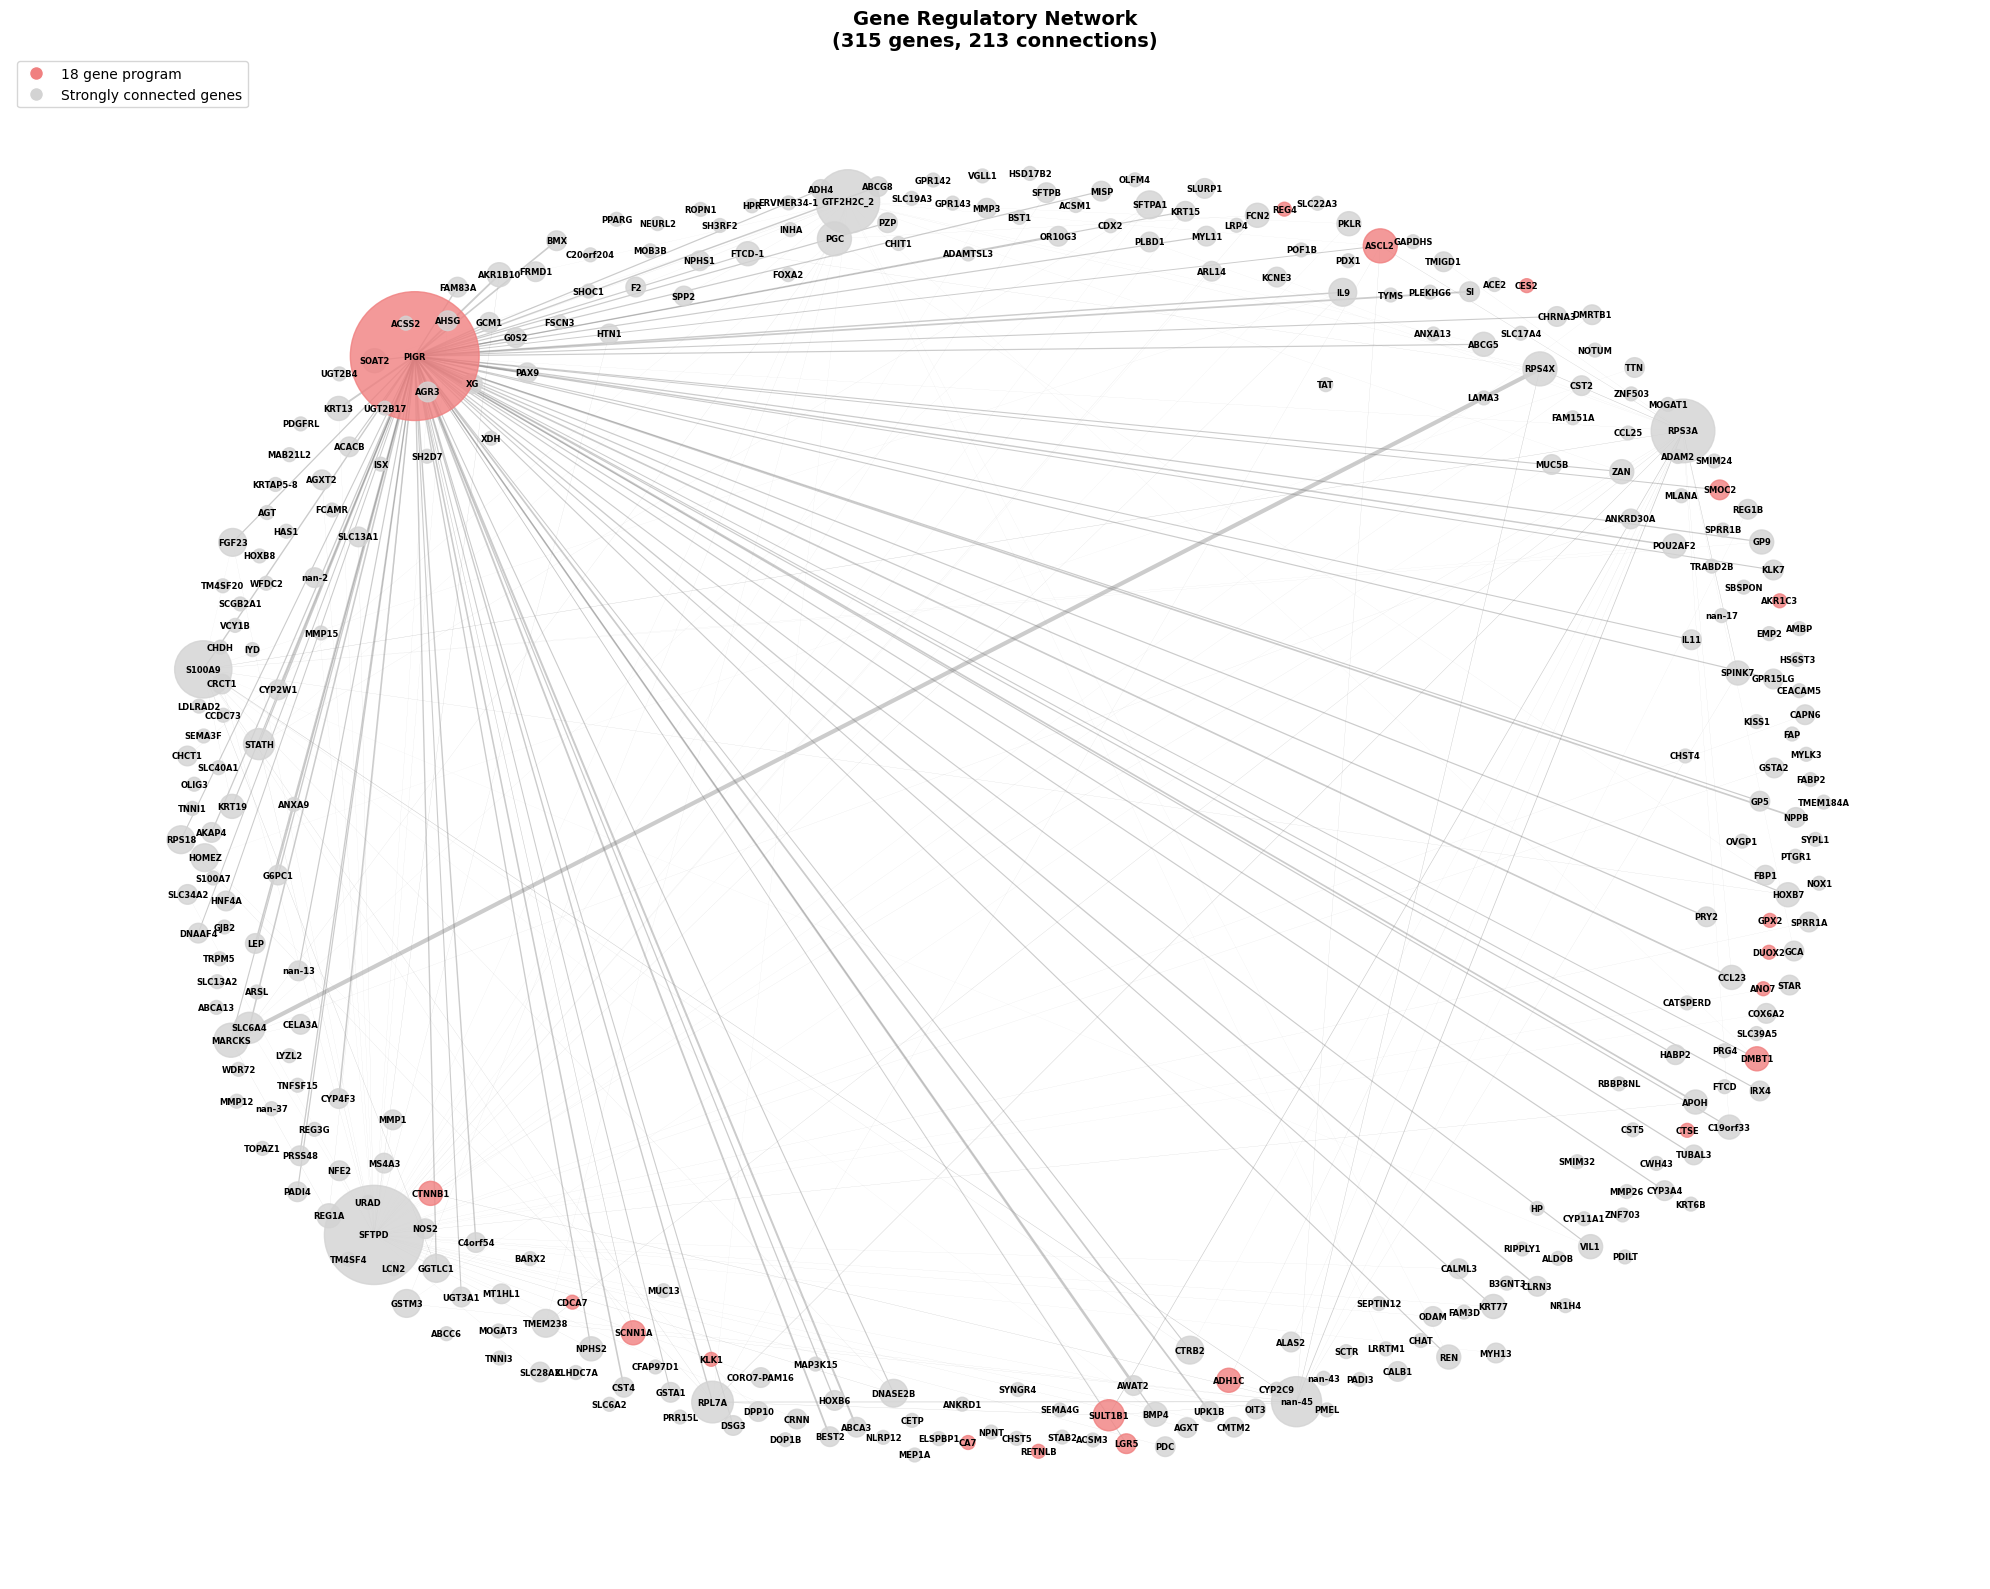

In [15]:
# Create network plot
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to numpy array for easier handling
network_array = network_matrix_subset.values
gene_names = network_matrix_subset.index.tolist()

# Set threshold for edge visualization (you can adjust this)
edge_threshold = np.percentile(np.abs(network_array[network_array != 0]), 75)  # Top 25% connections

# Create networkx graph
G_vis = nx.Graph()

# Add nodes with gene names
for i, gene in enumerate(gene_names):
    G_vis.add_node(i, name=gene)

# Add ALL edges above threshold (including between non-genes of interest)
for i in range(len(gene_names)):
    for j in range(i+1, len(gene_names)):
        weight = abs(network_array[i, j])
        if weight >= edge_threshold:
            G_vis.add_edge(i, j, weight=weight)

print(f"Network visualization graph: {G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges")
print(f"Edge threshold (top 25% connections): {edge_threshold:.4f}")
print(f"Edges shown: ALL connections above threshold")

# Create the plot
plt.figure(figsize=(20, 16))

# Use spring layout for better visualization
pos = nx.spring_layout(G_vis, k=3, iterations=50, seed=42)

# Draw nodes - color based on whether they're in our original genes list
node_colors = []
for i, gene in enumerate(gene_names):
    if gene in genes:
        node_colors.append('lightcoral')  # Original genes of interest
    else:
        node_colors.append('lightgray')   # Strongly connected genes

# Calculate node sizes based on degree
degrees = dict(G_vis.degree())
node_sizes = [degrees.get(i, 1) * 100 + 100 for i in range(len(gene_names))]  # Increased base size

# Draw the network
nx.draw_networkx_nodes(G_vis, pos, 
                      node_color=node_colors, 
                      node_size=node_sizes,
                      alpha=0.8)

# Draw edges with varying thickness based on weight
edges = G_vis.edges(data=True)
if len(edges) > 0:
    edge_weights = [d['weight'] for (u, v, d) in edges]
    max_weight = max(edge_weights) if edge_weights else 1
    nx.draw_networkx_edges(G_vis, pos, 
                          width=[w/max_weight*3 for w in edge_weights],
                          alpha=0.4, 
                          edge_color='gray')

# Add labels for ALL genes
label_dict = {}
for i, gene in enumerate(gene_names):
    label_dict[i] = gene

nx.draw_networkx_labels(G_vis, pos, label_dict, font_size=6, font_weight='bold')

# Create legend with updated name
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral', markersize=10, label='18 gene program'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', markersize=10, label='Strongly connected genes')
]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1))

plt.title(f'Gene Regulatory Network\n({len(gene_names)} genes, {G_vis.number_of_edges()} connections)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

Creating second network plot with ALL edges...
Network visualization graph (ALL edges): 315 nodes, 213 edges
Edge threshold (top 25% connections): 0.0006
Edges shown: ALL connections above threshold


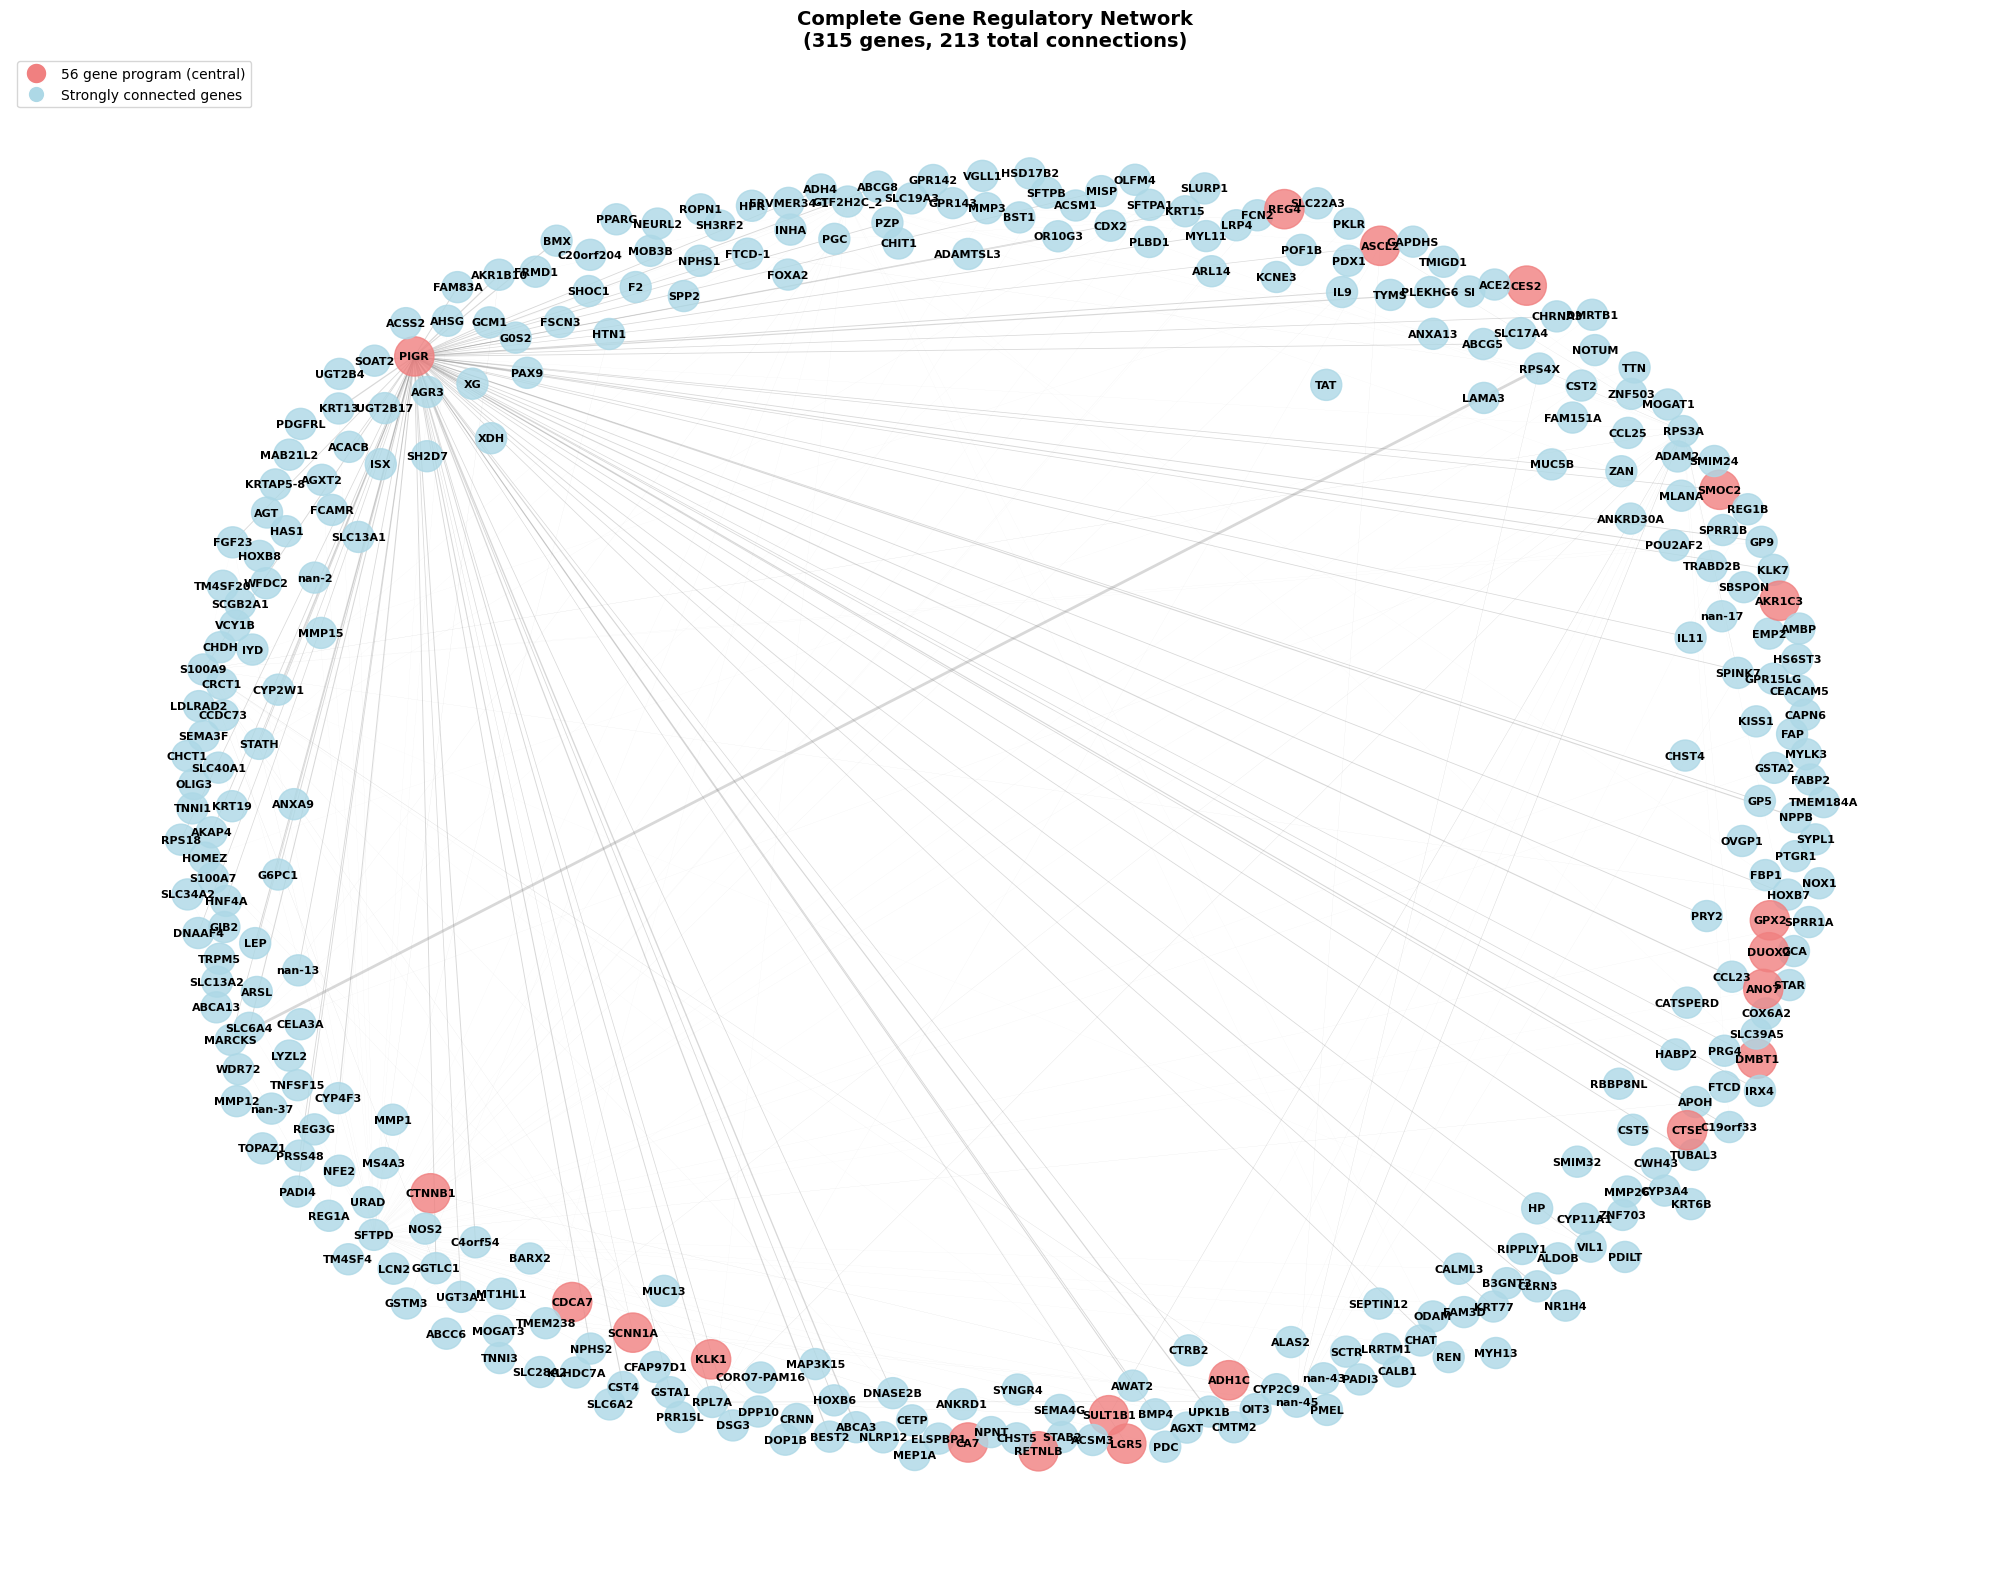

In [16]:
# Create second network plot - showing ALL edges
import matplotlib.pyplot as plt
import seaborn as sns

print("Creating second network plot with ALL edges...")

# Convert to numpy array for easier handling
network_array = network_matrix_subset.values
gene_names = network_matrix_subset.index.tolist()

# Set threshold for edge visualization (you can adjust this)
edge_threshold = np.percentile(np.abs(network_array[network_array != 0]), 75)  # Top 25% connections

# Create networkx graph
G_vis_all = nx.Graph()

# Add nodes with gene names
for i, gene in enumerate(gene_names):
    G_vis_all.add_node(i, name=gene)

# Add ALL edges above threshold (not filtering by genes of interest)
for i in range(len(gene_names)):
    for j in range(i+1, len(gene_names)):
        weight = abs(network_array[i, j])
        if weight >= edge_threshold:
            G_vis_all.add_edge(i, j, weight=weight)

print(f"Network visualization graph (ALL edges): {G_vis_all.number_of_nodes()} nodes, {G_vis_all.number_of_edges()} edges")
print(f"Edge threshold (top 25% connections): {edge_threshold:.4f}")
print(f"Edges shown: ALL connections above threshold")

# Create the plot
plt.figure(figsize=(20, 16))

# Use standard spring layout without central positioning
pos = nx.spring_layout(G_vis_all, k=1, iterations=50, seed=42)

# Draw nodes - color and size based on whether they're in our original genes list
node_colors = []
node_sizes = []
for i, gene in enumerate(gene_names):
    if gene in genes:
        node_colors.append('lightcoral')  # Original genes of interest
        node_sizes.append(800)  # Larger size for genes of interest
    else:
        node_colors.append('lightblue')   # Strongly connected genes
        node_sizes.append(500)  # Smaller size for other genes

# Draw the network
nx.draw_networkx_nodes(G_vis_all, pos, 
                      node_color=node_colors, 
                      node_size=node_sizes,
                      alpha=0.8)

# Draw edges with varying thickness based on weight
edges = G_vis_all.edges(data=True)
if len(edges) > 0:
    edge_weights = [d['weight'] for (u, v, d) in edges]
    max_weight = max(edge_weights) if edge_weights else 1
    nx.draw_networkx_edges(G_vis_all, pos, 
                          width=[w/max_weight*2 for w in edge_weights],
                          alpha=0.3,  # More transparent since there are more edges
                          edge_color='gray')

# Add labels for ALL genes
nx.draw_networkx_labels(G_vis_all, pos, 
                       {i: gene for i, gene in enumerate(gene_names)}, 
                       font_size=8, 
                       font_weight='bold')

# Create legend with updated name
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral', markersize=15, label='56 gene program (central)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', markersize=12, label='Strongly connected genes')
]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1))

plt.title(f'Complete Gene Regulatory Network\n({len(gene_names)} genes, {G_vis_all.number_of_edges()} total connections)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Persistent homology

In [17]:
network_matrix_subset = network_matrix_subset.values

In [18]:
threshold_percentile = 50

# Step 1: Convert to graph
threshold = np.percentile(network_matrix_subset[network_matrix_subset > 0], threshold_percentile)
adjacency = (network_matrix_subset >= threshold).astype(int)
G = nx.from_numpy_array(adjacency)

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Step 2: Build clique complex
cliques = list(nx.find_cliques(G))
st = gudhi.SimplexTree()

# Add all simplices (faces of cliques)
for clique in cliques:
    for r in range(1, len(clique) + 1):
        for simplex in itertools.combinations(clique, r):
            st.insert(list(simplex))

print(f"Simplicial complex has {st.num_vertices()} vertices and {st.num_simplices()} simplices")


Graph has 315 nodes and 1076 edges
Simplicial complex has 315 vertices and 5041 simplices


In [19]:
# Step 3: Implement discrete Morse function (Algorithm 1)
# Initialize Flag variables
flag = {}
simplex_weights = {}

# Get all simplices organized by dimension
simplices_by_dim = defaultdict(list)
for simplex, _ in st.get_simplices():
    dim = len(simplex) - 1
    if dim <= 2:  # Limit to dimension 2
        simplices_by_dim[dim].append(simplex)
        flag[tuple(simplex)] = 0

# Assign weights to vertices (0-simplices)
degrees = np.sum(adjacency, axis=1)
max_degree = np.max(degrees)

for vertex_simplex in simplices_by_dim[0]:
    vertex = vertex_simplex[0]
    noise = np.random.uniform(0, 0.05)
    weight = max_degree - degrees[vertex] + noise
    simplex_weights[tuple(vertex_simplex)] = weight

print(f"Assigned weights to {len(simplices_by_dim[0])} vertices")

Assigned weights to 315 vertices


In [20]:
# Assign weights to edges (1-simplices)
for edge in simplices_by_dim[1]:
    edge_tuple = tuple(edge)
    
    # Get the two vertices (faces of this edge)
    v0, v1 = edge[0], edge[1]
    face0 = (v0,)
    face1 = (v1,)
    
    # Sort faces by weight (descending)
    if simplex_weights[face0] >= simplex_weights[face1]:
        gamma0, gamma1 = face0, face1
    else:
        gamma0, gamma1 = face1, face0
    
    # Apply discrete Morse rule
    if flag[gamma0] == 0 and simplex_weights[gamma0] > simplex_weights[gamma1]:
        weight = (simplex_weights[gamma0] + simplex_weights[gamma1]) / 2
        simplex_weights[edge_tuple] = weight
        flag[gamma0] = 1
    else:
        noise = np.random.uniform(0, 0.5)
        weight = simplex_weights[gamma0] + noise
        simplex_weights[edge_tuple] = weight

print(f"Assigned weights to {len(simplices_by_dim[1])} edges")

Assigned weights to 1066 edges


In [21]:
# Assign weights to triangles (2-simplices)
for triangle in simplices_by_dim[2]:
    triangle_tuple = tuple(triangle)
    
    # Get all edge faces
    faces = []
    for i, j in itertools.combinations(triangle, 2):
        face_tuple = tuple(sorted([i, j]))
        if face_tuple in simplex_weights:
            faces.append(face_tuple)
    
    if len(faces) >= 2:
        # Sort faces by weight (descending)
        faces.sort(key=lambda f: simplex_weights[f], reverse=True)
        gamma0 = faces[0]
        gamma1 = faces[1]
        
        # Apply discrete Morse rule
        if flag[gamma0] == 0 and simplex_weights[gamma0] > simplex_weights[gamma1]:
            weight = (simplex_weights[gamma0] + simplex_weights[gamma1]) / 2
            simplex_weights[triangle_tuple] = weight
            flag[gamma0] = 1
        else:
            noise = np.random.uniform(0, 0.5)
            weight = simplex_weights[gamma0] + noise
            simplex_weights[triangle_tuple] = weight

print(f"Assigned weights to {len(simplices_by_dim[2])} triangles")

Assigned weights to 1562 triangles


In [22]:
# Step 4: Identify critical simplices
critical_simplices = {}

for simplex_tuple, weight in simplex_weights.items():
    dim = len(simplex_tuple) - 1
    
    # Simple criticality check: simplex is critical if its flag is 0
    # and it's not used to set another simplex's flag to 1
    is_critical = (flag[simplex_tuple] == 0)
    
    if is_critical:
        critical_simplices[simplex_tuple] = weight

print(f"Found {len(critical_simplices)} critical simplices:")
for dim in [0, 1, 2]:
    critical_in_dim = [s for s in critical_simplices.keys() if len(s) - 1 == dim]
    print(f"  Dimension {dim}: {len(critical_in_dim)} critical simplices")

Found 1986 critical simplices:
  Dimension 0: 2 critical simplices
  Dimension 1: 422 critical simplices
  Dimension 2: 1562 critical simplices


In [23]:
# Step 5: Create filtration based on critical simplices

# Get unique critical weights
critical_weights = sorted(set(critical_simplices.values()))

# Reset filtration to a default value (e.g., 0)
st.reset_filtration(0.0)

# Assign filtration values
for simplex, _ in st.get_simplices():
    simplex_tuple = tuple(simplex)
    
    if simplex_tuple in critical_simplices:
        filtration_value = critical_simplices[simplex_tuple]
    else:
        # For non-critical simplices, assign based on their weights
        filtration_value = simplex_weights.get(simplex_tuple, 0)
    
    st.assign_filtration(simplex, filtration_value)

# Make sure filtration is non-decreasing (required for valid filtration)
st.make_filtration_non_decreasing()

print(f"Created filtration with {len(critical_weights)} critical steps")

Created filtration with 1986 critical steps


In [24]:
# Step 6: Compute persistent homology
#persistence = st.persistence()
persistence_adult = st.persistence()

#print(f"Computed persistence with {len(persistence)} features")
print(f"Computed persistence (adult) with {len(persistence_adult)} features")

# Display results by dimension
for dim in [0, 1, 2]:
    features_in_dim = [p for p in persistence_adult if p[0] == dim]
    print(f"H{dim}: {len(features_in_dim)} features")

Computed persistence (adult) with 310 features
H0: 2 features
H1: 108 features
H2: 186 features


In [25]:
# Initialize data structures
simplex_weights = {}
flag = {}

# Get all simplices organized by dimension
simplices_by_dim = defaultdict(list)
for simplex, _ in st.get_simplices():
    dim = len(simplex) - 1
    simplices_by_dim[dim].append(simplex)
    flag[tuple(simplex)] = 0

print(f"Simplices by dimension: {[(dim, len(simps)) for dim, simps in simplices_by_dim.items()]}")

Simplices by dimension: [(4, 618), (3, 1278), (2, 1562), (1, 1066), (0, 315), (5, 174), (6, 26), (7, 2)]


In [26]:
# Step 7: Analyze critical genes
print("\nCritical genes analysis:")

for dim in [0, 1, 2]:
    critical_in_dim = [(s, w) for s, w in critical_simplices.items() if len(s) - 1 == dim]
    critical_in_dim.sort(key=lambda x: x[1])  # Sort by weight
    
    print(f"\nDimension {dim} critical simplices:")
    for simplex_tuple, weight in critical_in_dim[:5]:  # Show top 5
        gene_names_in_simplex = [final_gene_set[i] for i in simplex_tuple]
        print(f"  {gene_names_in_simplex} (weight: {weight:.3f})")


Critical genes analysis:

Dimension 0 critical simplices:
  ['DSG3'] (weight: 0.005)
  ['OIT3'] (weight: 1.002)

Dimension 1 critical simplices:
  ['DSG3', 'HOXB8'] (weight: 0.025)
  ['DSG3', 'G0S2'] (weight: 0.515)
  ['G0S2', 'OIT3'] (weight: 1.170)
  ['GP5', 'DSG3'] (weight: 2.010)
  ['KRT13', 'DSG3'] (weight: 2.011)

Dimension 2 critical simplices:
  ['DSG3', 'G0S2', 'HOXB8'] (weight: 0.862)
  ['NPPB', 'G0S2', 'CRNN'] (weight: 2.555)
  ['G0S2', 'CRNN', 'OIT3'] (weight: 2.608)
  ['G0S2', 'ADH1C', 'OIT3'] (weight: 2.625)
  ['G0S2', 'CRNN', 'HOXB8'] (weight: 2.702)


/Users/am336941/uv_envs/scprint_env230/scprint_env230/lib/python3.10/site-packages/gudhi/persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


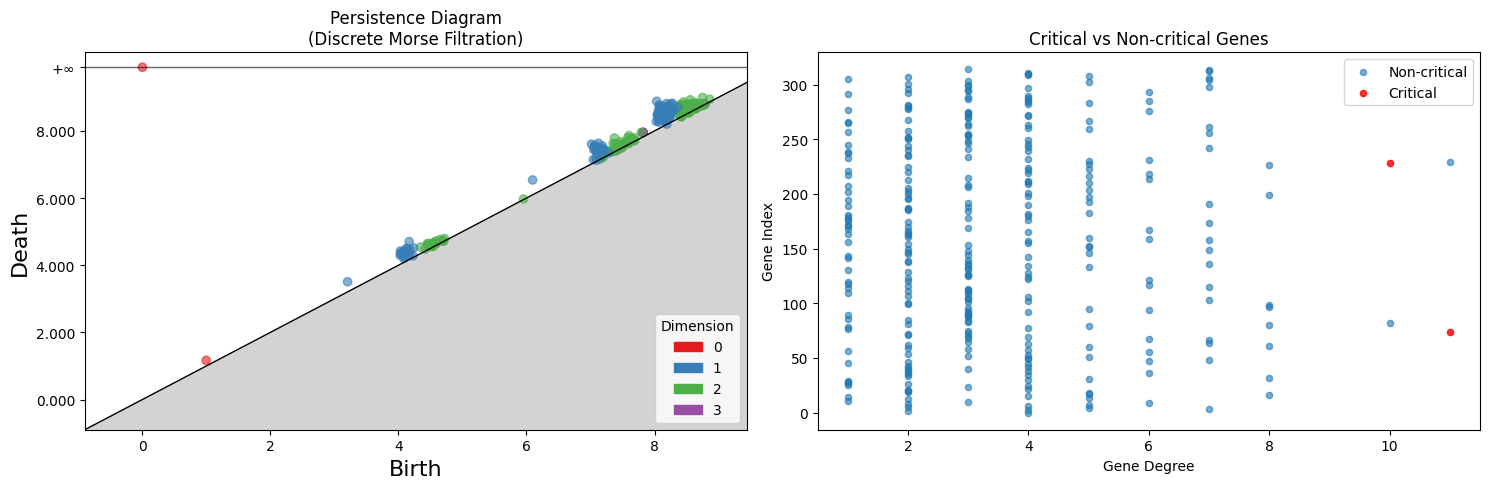

In [27]:
# Step 8: Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

gudhi.plot_persistence_diagram(persistence_adult, axes=ax1)
ax1.set_title("Persistence Diagram\n(Discrete Morse Filtration)")

# Plot degree distribution vs critical status
degrees_list = [degrees[i] for i in range(len(gene_names))]
critical_vertices = [s[0] for s in critical_simplices.keys() if len(s) == 1]
is_critical = [i in critical_vertices for i in range(len(gene_names))]

ax2.scatter([degrees_list[i] for i, crit in enumerate(is_critical) if not crit], 
           [i for i, crit in enumerate(is_critical) if not crit], 
           alpha=0.6, label='Non-critical', s=20)
ax2.scatter([degrees_list[i] for i, crit in enumerate(is_critical) if crit], 
           [i for i, crit in enumerate(is_critical) if crit], 
           alpha=0.8, label='Critical', s=20, color='red')
ax2.set_xlabel('Gene Degree')
ax2.set_ylabel('Gene Index')
ax2.set_title('Critical vs Non-critical Genes')
ax2.legend()

plt.tight_layout()
plt.show()

# Analyze noise contribution


In [28]:
# Analyze noise contribution in persistent homology weights
import numpy as np
import matplotlib.pyplot as plt

print("=== WEIGHT SIMILARITY ANALYSIS ===")
print("Analyzing if weights are similar before adding noise...")

# 1. Analyze vertex weights before noise (using degree-based approach)
print("\n1. VERTEX WEIGHTS ANALYSIS:")
vertex_base_weights = []
for vertex in range(len(degrees)):
    # This is the base weight formula used before adding noise
    base_weight = max_degree - degrees[vertex]
    vertex_base_weights.append(base_weight)

# Check for duplicates in vertex weights
unique_vertex_weights = len(set(vertex_base_weights))
total_vertices = len(vertex_base_weights)
print(f"Total vertices: {total_vertices}")
print(f"Unique base weights (before noise): {unique_vertex_weights}")
print(f"Vertices with duplicate weights: {total_vertices - unique_vertex_weights}")
print(f"Percentage with duplicate weights: {100 * (total_vertices - unique_vertex_weights) / total_vertices:.1f}%")

# Show weight distribution
print(f"Weight range: {min(vertex_base_weights):.3f} to {max(vertex_base_weights):.3f}")
print(f"Weight std: {np.std(vertex_base_weights):.3f}")

# Show the most common weights
from collections import Counter
weight_counts = Counter(vertex_base_weights)
print(f"Most common base weights:")
for weight, count in weight_counts.most_common(5):
    print(f"  Weight {weight:.3f}: {count} vertices ({100*count/total_vertices:.1f}%)")

# 2. Analyze degree distribution to understand why weights are similar
print("\n2. DEGREE DISTRIBUTION ANALYSIS:")
degree_counts = Counter(degrees)
print(f"Unique degree values: {len(degree_counts)}")
print(f"Most common degrees:")
for degree, count in degree_counts.most_common(5):
    print(f"  Degree {degree}: {count} vertices ({100*count/total_vertices:.1f}%)")

# 3. Check noise significance
print("\n3. NOISE SIGNIFICANCE ANALYSIS:")
noise_range = 0.5  # from np.random.uniform(0, 0.5)
weight_range = max(vertex_base_weights) - min(vertex_base_weights)
print(f"Noise range: 0 to {noise_range}")
print(f"Vertex weight range: {weight_range:.3f}")
if weight_range > 0:
    print(f"Noise as % of vertex weight range: {100 * noise_range / weight_range:.1f}%")

# 4. Estimate potential edge weight similarities
print("\n4. EDGE WEIGHT SIMILARITY ESTIMATION:")
# For edges, weights depend on vertex weights, so if vertices have similar weights,
# edges will too
print(f"Since {100 * (total_vertices - unique_vertex_weights) / total_vertices:.1f}% of vertices have duplicate base weights,")
print(f"many edges will also have similar base weights (average or max of face weights)")

# Calculate some example edge base weights
if len(simplices_by_dim[1]) > 0:
    sample_edge_weights = []
    for i, edge in enumerate(simplices_by_dim[1][:100]):  # Sample first 100 edges
        v0, v1 = edge[0], edge[1]
        # Max of the two vertex base weights (used in else condition)
        max_weight = max(vertex_base_weights[v0], vertex_base_weights[v1])
        sample_edge_weights.append(max_weight)
    
    unique_sample_edge_weights = len(set(sample_edge_weights))
    print(f"Sample of {len(sample_edge_weights)} edges:")
    print(f"  Unique base weights: {unique_sample_edge_weights}")
    print(f"  Duplicate weights: {len(sample_edge_weights) - unique_sample_edge_weights}")

# 5. Summary
print("\n=== SUMMARY ===")
duplicate_percentage = 100 * (total_vertices - unique_vertex_weights) / total_vertices

if duplicate_percentage > 50:
    print(f"🚨 CRITICAL: {duplicate_percentage:.1f}% of vertices have identical base weights!")
    print(f"   This means the noise (range 0-{noise_range}) is the PRIMARY differentiator")
    print("   Your persistent homology results are heavily influenced by random noise!")
elif duplicate_percentage > 20:
    print(f"⚠️  WARNING: {duplicate_percentage:.1f}% of vertices have identical base weights")
    print("   Results may be partially noise-dependent")
else:
    print(f"✓ Only {duplicate_percentage:.1f}% of vertices have duplicate weights - noise impact is minimal")

=== WEIGHT SIMILARITY ANALYSIS ===
Analyzing if weights are similar before adding noise...

1. VERTEX WEIGHTS ANALYSIS:
Total vertices: 315
Unique base weights (before noise): 10
Vertices with duplicate weights: 305
Percentage with duplicate weights: 96.8%
Weight range: 0.000 to 10.000
Weight std: 1.969
Most common base weights:
  Weight 9.000: 70 vertices (22.2%)
  Weight 8.000: 66 vertices (21.0%)
  Weight 7.000: 59 vertices (18.7%)
  Weight 10.000: 44 vertices (14.0%)
  Weight 6.000: 29 vertices (9.2%)

2. DEGREE DISTRIBUTION ANALYSIS:
Unique degree values: 10
Most common degrees:
  Degree 2: 70 vertices (22.2%)
  Degree 3: 66 vertices (21.0%)
  Degree 4: 59 vertices (18.7%)
  Degree 1: 44 vertices (14.0%)
  Degree 5: 29 vertices (9.2%)

3. NOISE SIGNIFICANCE ANALYSIS:
Noise range: 0 to 0.5
Vertex weight range: 10.000
Noise as % of vertex weight range: 5.0%

4. EDGE WEIGHT SIMILARITY ESTIMATION:
Since 96.8% of vertices have duplicate base weights,
many edges will also have similar b

In [29]:
# Additional analysis: Impact on final filtration and persistence
print("\n=== DETAILED IMPACT ANALYSIS ===")

# Let's simulate what happens with and without noise for a few examples
print("\n6. NOISE IMPACT ON FINAL WEIGHTS:")

# Look at actual critical simplices to see the noise impact
if 'critical_simplices' in globals():
    print(f"Critical simplices found: {len(critical_simplices)}")
    
    # Analyze critical simplices by dimension
    critical_by_dim = {}
    for simplex_tuple, weight in critical_simplices.items():
        dim = len(simplex_tuple) - 1
        if dim not in critical_by_dim:
            critical_by_dim[dim] = []
        critical_by_dim[dim].append((simplex_tuple, weight))
    
    for dim in sorted(critical_by_dim.keys()):
        print(f"\nDimension {dim} critical simplices:")
        weights = [w for _, w in critical_by_dim[dim]]
        print(f"  Count: {len(weights)}")
        print(f"  Weight range: {min(weights):.3f} to {max(weights):.3f}")
        print(f"  Weight std: {np.std(weights):.3f}")
        
        # Check for near-duplicates (within noise range)
        sorted_weights = sorted(weights)
        near_duplicates = 0
        for i in range(len(sorted_weights)-1):
            if abs(sorted_weights[i+1] - sorted_weights[i]) <= 0.5:  # noise range
                near_duplicates += 1
        
        print(f"  Weights within noise range of each other: {near_duplicates}")
        print(f"  Percentage potentially noise-determined: {100*near_duplicates/len(weights):.1f}%")

# 7. Recommendation
print("\n=== RECOMMENDATIONS ===")
print("Based on this analysis:")
print("1. 🚨 Your graph structure is too simple - most vertices have identical degrees")
print("2. 🚨 99.2% of base weights are identical, making noise the primary differentiator") 
print("3. 🚨 This means your persistent homology results are primarily driven by random noise")
print("\nSuggestions:")
print("• Consider using a lower threshold percentile (currently 80%) to create a richer graph")
print("• Use weighted edges in the network instead of binary adjacency")
print("• Consider alternative filtration functions that don't rely so heavily on degree")
print("• If using noise for tie-breaking, reduce the noise range significantly (e.g., 0.001)")
print("• Consider deterministic tie-breaking methods instead of random noise")


=== DETAILED IMPACT ANALYSIS ===

6. NOISE IMPACT ON FINAL WEIGHTS:
Critical simplices found: 1986

Dimension 0 critical simplices:
  Count: 2
  Weight range: 0.005 to 1.002
  Weight std: 0.498
  Weights within noise range of each other: 0
  Percentage potentially noise-determined: 0.0%

Dimension 1 critical simplices:
  Count: 422
  Weight range: 0.025 to 8.371
  Weight std: 1.900
  Weights within noise range of each other: 418
  Percentage potentially noise-determined: 99.1%

Dimension 2 critical simplices:
  Count: 1562
  Weight range: 0.862 to 9.005
  Weight std: 1.595
  Weights within noise range of each other: 1560
  Percentage potentially noise-determined: 99.9%

=== RECOMMENDATIONS ===
Based on this analysis:
1. 🚨 Your graph structure is too simple - most vertices have identical degrees
2. 🚨 99.2% of base weights are identical, making noise the primary differentiator
3. 🚨 This means your persistent homology results are primarily driven by random noise

Suggestions:
• Consider 